In [1]:
from resources.imports import *

In [2]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch import optim
from torch.utils.data import DataLoader
from torchinfo import summary

from resources.MLdata import *
from resources.MLfunc import *
from resources.MLmodels import Autoencoder

In [3]:
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt

In [17]:
DAT = DATA(path=1, load=True, LAT="FCC", dis="disNodes", dN=20, model="MLP", format=1)
DAT.train_in.shape

(353, 900)

# Principal Component Analysis (PCA)

In [5]:
X_data = DAT.train_in

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X_data)

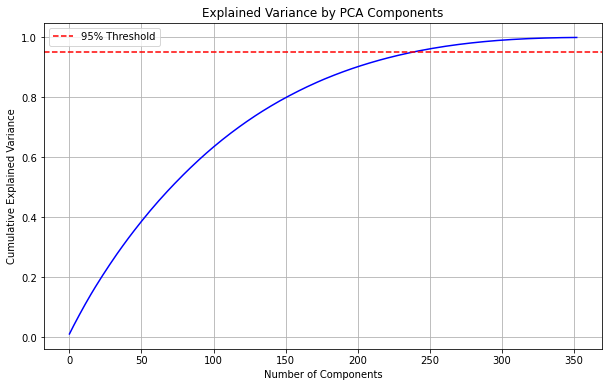

Number of components to capture 95% variance: 239
Number of components to capture 100% variance: 352


In [6]:
pca = PCA()
pca.fit(X_scaled)

plt.figure(figsize=(10, 6))
plt.plot(np.cumsum(pca.explained_variance_ratio_), 'b-')
plt.xlabel('Number of Components')
plt.ylabel('Cumulative Explained Variance')
plt.title('Explained Variance by PCA Components')
plt.grid(True)
plt.axhline(y=0.95, color='r', linestyle='--', label='95% Threshold')
plt.legend()
plt.show()

n_components_95 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 0.95)[0][0] + 1
n_components_100 = np.where(np.cumsum(pca.explained_variance_ratio_) >= 1)[0][0] + 1
print(f"Number of components to capture 95% variance: {n_components_95}")
print(f"Number of components to capture 100% variance: {n_components_100}")

In [7]:
final_pca = PCA(n_components=n_components_95)
X_reduced = final_pca.fit_transform(X_scaled)

print(f"Original data shape: {X_data.shape}")
print(f"Reduced data shape: {X_reduced.shape}")

Original data shape: (353, 900)
Reduced data shape: (353, 239)


In [9]:
# Let's say your GA/SA finds an optimal vector in the PCA space
# This is a hypothetical result from your optimizer
optimal_pca_vector = np.random.randn(1, n_components_95) 

optimal_scaled_vector = final_pca.inverse_transform(optimal_pca_vector)
final_optimal_displacements = scaler.inverse_transform(optimal_scaled_vector)

print(f"Final optimized lattice displacement vector shape: {final_optimal_displacements.shape}")

Final optimized lattice displacement vector shape: (1, 900)


# Autoencoder

In [10]:
in_size = DAT.train_in.shape[-1]
h_size = [100]
latent_size = 20

BATCH_SIZE = 1
LEARNING_RATE = 1e-3
n_epochs = 5000

In [11]:
trainDS = Dataset_(DAT.train_in[:100], DAT.train_in[:100])
train_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=True)
test_dataloader = DataLoader(dataset=trainDS, batch_size=BATCH_SIZE, shuffle=False)

In [12]:
model = Autoencoder(in_size=in_size, latent_size=latent_size, h_size=h_size)

opt = optim.Adam(model.parameters(), lr=LEARNING_RATE) 
lossf = nn.MSELoss()

earlyStop = EarlyStopping(patience=100, min_delta=1e-4, verbose=True)
ReduceLR = optim.lr_scheduler.ReduceLROnPlateau(opt, mode="min", factor=0.7, patience=6, threshold=1e-4, verbose=True)

summary(model, input_size=(BATCH_SIZE, in_size))

c:\Programs\Python39\lib\site-packages\torch\optim\lr_scheduler.py:62: UserWarning: The verbose parameter is deprecated. Please use get_last_lr() to access the learning rate.
  warnings.warn(


Layer (type:depth-idx)                   Output Shape              Param #
Autoencoder                              [1, 900]                  --
├─MLP: 1-1                               [1, 20]                   --
│    └─Linear: 2-1                       [1, 100]                  90,100
│    └─Sigmoid: 2-2                      [1, 100]                  --
│    └─Linear: 2-3                       [1, 20]                   2,020
├─MLP: 1-2                               [1, 900]                  --
│    └─Linear: 2-4                       [1, 100]                  2,100
│    └─Sigmoid: 2-5                      [1, 100]                  --
│    └─Linear: 2-6                       [1, 900]                  90,900
Total params: 185,120
Trainable params: 185,120
Non-trainable params: 0
Total mult-adds (M): 0.19
Input size (MB): 0.00
Forward/backward pass size (MB): 0.01
Params size (MB): 0.74
Estimated Total Size (MB): 0.75

In [13]:
model_train = TrainModel("mpl", model, lossf, n_epochs, opt, train_dataloader, 
                        scheduler=ReduceLR, earlyStop=earlyStop, verbose=50, run=True)

model = model_train.model

Epoch: 1 - Loss: 0.6949019432067871
Epoch: 50 - Loss: 0.26875531673431396
Epoch: 100 - Loss: 0.13598228991031647
Epoch: 150 - Loss: 0.08745721727609634
Epoch: 200 - Loss: 0.031333379447460175
Epoch: 250 - Loss: 0.023280341178178787
Epoch: 300 - Loss: 0.007950515486299992
Epoch: 350 - Loss: 0.0024573849514126778
Epoch: 400 - Loss: 0.01404319517314434
Epoch: 450 - Loss: 0.0014217296848073602
Epoch: 500 - Loss: 0.0019006648799404502
Epoch: 550 - Loss: 0.0008751327404752374
Epoch: 600 - Loss: 0.0011283947387710214
Epoch: 650 - Loss: 0.0007194534409791231
Epoch: 700 - Loss: 0.00041040367796085775
Epoch: 750 - Loss: 0.0014574918895959854
Epoch: 800 - Loss: 0.0005721100606024265
Epoch: 850 - Loss: 0.0005064381984993815
Epoch: 900 - Loss: 0.00014842134260106832
Epoch: 950 - Loss: 5.90617855777964e-05
Epoch: 1000 - Loss: 7.057446055114269e-05
Epoch: 1050 - Loss: 2.5539127818774432e-05
Epoch: 1100 - Loss: 5.271374175208621e-05
Early stopping triggered after 100 epochs without improvement.
Best E

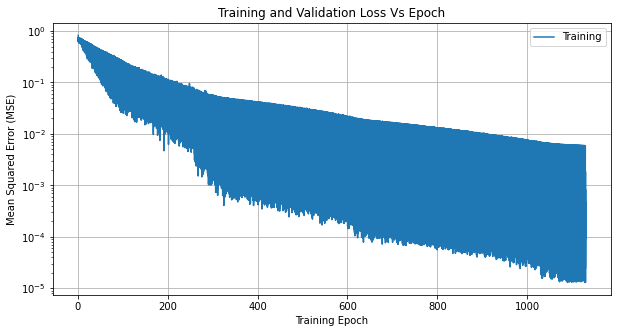

In [14]:
plot_loss(model_train.epoch, model_train.train_lossLog)

In [15]:
test_outputs = predict_model("mlp", model, test_dataloader)

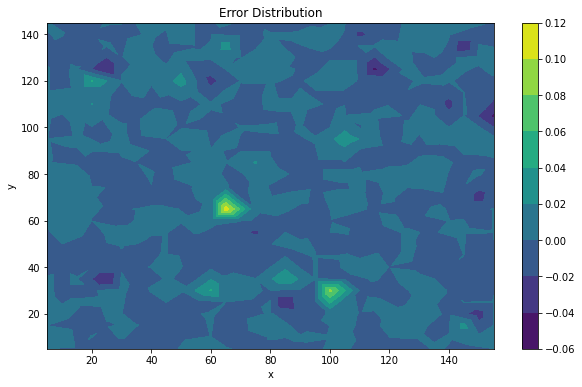

In [44]:
indx = 0
xy = 0

plt_outputs = test_outputs[indx].reshape(len(test_outputs[0])//2, 2)[:,xy]
truth = DAT.train_in[indx].reshape(len(test_outputs[0])//2,2)[:,xy]

plot_Distribution(DAT.train_in1, plt_outputs, truth=truth)